# K-Means Career Recommendation System

This notebook implements a career recommendation system using **K-Means Clustering** to group similar careers and recommend from the user's cluster.

## Step 1: Import Required Libraries

In [1]:
import json
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## Step 2: Load Career Dataset

In [2]:
# Load careers dataset
with open("careers_dataset_50plus.json", "r") as f:
    careers_data = json.load(f)

print(f"✅ Loaded {len(careers_data)} careers from dataset")
print(f"\nSample career: {careers_data[0]['career_name']}")

✅ Loaded 60 careers from dataset

Sample career: Data Scientist


## Step 3: Prepare Career Data

In [3]:
def safe_list_to_string(data):
    """Convert list or string to clean string format"""
    if isinstance(data, list):
        return " ".join([str(item) for item in data if item])
    elif isinstance(data, str):
        return data
    else:
        return ""

# Create DataFrame
careers_df = pd.DataFrame(careers_data)

# Combine all text fields for each career
def combine_career_text(row):
    parts = []
    parts.append(str(row.get('career_name', '')))
    parts.append(str(row.get('category', '')))
    parts.append(safe_list_to_string(row.get('required_skills', [])))
    parts.append(safe_list_to_string(row.get('recommended_courses', [])))
    parts.append(safe_list_to_string(row.get('projects', [])))
    parts.append(str(row.get('roadmap', '')))
    return " ".join([p for p in parts if p])

careers_df['combined_text'] = careers_df.apply(combine_career_text, axis=1)

print(f"✅ Prepared {len(careers_df)} career profiles")
print(f"\nFirst career combined text preview:")
print(careers_df['combined_text'].iloc[0][:200] + "...")

✅ Prepared 60 career profiles

First career combined text preview:
Data Scientist Artificial Intelligence Python Machine Learning Statistics SQL Pandas TensorFlow Data Visualization Communication Big Data Storytelling Machine Learning by Andrew Ng (Coursera) IBM Data...


## Step 4: Build TF-IDF Matrix

In [4]:
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1, 2),
    min_df=1
)

# Fit and transform career texts
tfidf_matrix = tfidf.fit_transform(careers_df['combined_text'])

print(f"✅ TF-IDF matrix created: {tfidf_matrix.shape}")
print(f"   - {tfidf_matrix.shape[0]} careers")
print(f"   - {tfidf_matrix.shape[1]} features (terms)")

✅ TF-IDF matrix created: (60, 2926)
   - 60 careers
   - 2926 features (terms)


## Step 5: Apply K-Means Clustering

In [5]:
# Determine optimal number of clusters (typically 5-10 for career grouping)
n_clusters = min(8, len(careers_df) // 5)  # Ensure at least 5 careers per cluster on average

print(f"\n🔧 Applying K-Means clustering with {n_clusters} clusters...")

# Initialize and fit K-Means
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10,
    max_iter=300
)

# Get cluster labels
cluster_labels = kmeans.fit_predict(tfidf_matrix)
careers_df['cluster'] = cluster_labels

print(f"✅ K-Means clustering complete!")
print(f"\n📊 Cluster Distribution:")
print(careers_df['cluster'].value_counts().sort_index())

# Show sample careers from each cluster
print(f"\n🔍 Sample Careers from Each Cluster:\n")
for cluster_id in range(n_clusters):
    cluster_careers = careers_df[careers_df['cluster'] == cluster_id]['career_name'].head(3).tolist()
    print(f"Cluster {cluster_id}: {', '.join(cluster_careers)}")


🔧 Applying K-Means clustering with 8 clusters...
✅ K-Means clustering complete!

📊 Cluster Distribution:
cluster
0     8
1     7
2    17
3     3
4     9
5     8
6     4
7     4
Name: count, dtype: int64

🔍 Sample Careers from Each Cluster:

Cluster 0: Data Scientist, Product Manager, Data Analyst
Cluster 1: Cloud Engineer, Cybersecurity Analyst, IoT Engineer
Cluster 2: Mechanical Design Engineer, Electrical Engineer, Electronics Engineer
Cluster 3: Digital Marketing Specialist, Content Writer, Digital Marketing Analyst
Cluster 4: Civil Engineer, UI/UX Designer, Civil Engineer
Cluster 5: Software Engineer, AI Research Scientist, AI Engineer
Cluster 6: Blockchain Developer, Cybersecurity Analyst, Blockchain Developer
Cluster 7: Game Developer, AR/VR Developer, Game Developer


## Step 6: Define Recommendation Function

In [6]:
def recommend_careers_kmeans(user_profile, top_k=5):
    """
    Recommend careers based on user profile using K-Means Clustering
    
    Process:
    1. Transform user profile to TF-IDF vector
    2. Find which cluster the user belongs to
    3. Rank careers within that cluster by similarity
    4. Return top K recommendations
    
    Args:
        user_profile (dict): User's profile containing skills, interests, etc.
        top_k (int): Number of recommendations to return
    
    Returns:
        list: Top K recommended careers with scores
    """
    # Combine user profile into text
    user_text_parts = []
    user_text_parts.append(user_profile.get('department', ''))
    user_text_parts.append(user_profile.get('interests', ''))
    user_text_parts.append(' '.join(user_profile.get('skills', [])))
    user_text_parts.append(' '.join(user_profile.get('projects', [])))
    user_text_parts.append(' '.join(user_profile.get('certifications', [])))
    
    user_text = ' '.join([p for p in user_text_parts if p])
    
    print(f"\n🔍 User Profile Text:\n{user_text}\n")
    
    # Transform user text using TF-IDF
    user_vector = tfidf.transform([user_text])
    
    # Predict cluster for user
    user_cluster = kmeans.predict(user_vector)[0]
    
    print(f"📍 User assigned to Cluster: {user_cluster}")
    
    # Get careers from the same cluster
    cluster_careers = careers_df[careers_df['cluster'] == user_cluster].copy()
    
    print(f"📦 Found {len(cluster_careers)} careers in this cluster\n")
    
    # Calculate similarity within the cluster
    cluster_indices = cluster_careers.index.tolist()
    cluster_tfidf = tfidf_matrix[cluster_indices]
    
    similarities = cosine_similarity(user_vector, cluster_tfidf)[0]
    
    # Get top K indices within the cluster
    top_local_indices = similarities.argsort()[-top_k:][::-1]
    top_global_indices = [cluster_indices[i] for i in top_local_indices]
    
    # Prepare results
    recommendations = []
    for idx, local_idx in zip(top_global_indices, top_local_indices):
        career = careers_data[idx]
        recommendations.append({
            'career_name': career['career_name'],
            'category': career.get('category', 'N/A'),
            'cluster': int(user_cluster),
            'similarity_score': float(similarities[local_idx]),
            'required_skills': career.get('required_skills', []),
            'recommended_courses': career.get('recommended_courses', []),
            'roadmap': career.get('roadmap', 'N/A')
        })
    
    return recommendations

print("✅ Recommendation function defined")

✅ Recommendation function defined


## Step 7: Get User Input

In [7]:
# Collect user input
print("\n" + "="*60)
print("      WELCOME TO K-MEANS CAREER RECOMMENDER SYSTEM")
print("="*60 + "\n")

name = input("Enter your name: ").strip()
department = input("Enter your department (e.g., CSE, ECE, MECH): ").strip()
skills_input = input("Enter your skills (comma-separated): ").strip()
interests = input("Enter your career interests: ").strip()
projects_input = input("Enter your projects (comma-separated): ").strip()
certifications_input = input("Enter your certifications (comma-separated): ").strip()

# Parse inputs
skills = [s.strip() for s in skills_input.split(',') if s.strip()]
projects = [p.strip() for p in projects_input.split(',') if p.strip()]
certifications = [c.strip() for c in certifications_input.split(',') if c.strip()]

# Create user profile
user_profile = {
    'name': name,
    'department': department,
    'skills': skills,
    'interests': interests,
    'projects': projects,
    'certifications': certifications
}

print("\n✅ Profile created successfully!")


      WELCOME TO K-MEANS CAREER RECOMMENDER SYSTEM


✅ Profile created successfully!

✅ Profile created successfully!


## Step 8: Generate Recommendations

In [8]:
# Get recommendations
print("\n" + "="*60)
print(f"  CAREER RECOMMENDATIONS FOR {user_profile['name'].upper()}")
print("="*60)

recommendations = recommend_careers_kmeans(user_profile, top_k=5)

# Display recommendations
print(f"\n🎯 Top 5 Career Recommendations (K-Means Method):\n")

for i, rec in enumerate(recommendations, 1):
    print(f"\n{'='*60}")
    print(f"Rank #{i}: {rec['career_name']}")
    print(f"{'='*60}")
    print(f"📊 Similarity Score: {rec['similarity_score']:.4f}")
    print(f"📍 Cluster: {rec['cluster']}")
    print(f"📁 Category: {rec['category']}")
    print(f"\n💡 Required Skills:")
    for skill in rec['required_skills'][:5]:  # Show top 5 skills
        print(f"   • {skill}")
    print(f"\n📚 Recommended Courses:")
    for course in rec['recommended_courses'][:3]:  # Show top 3 courses
        print(f"   • {course}")
    print(f"\n🗺️ Career Roadmap:")
    print(f"   {rec['roadmap'][:150]}..." if len(rec['roadmap']) > 150 else f"   {rec['roadmap']}")

print("\n" + "="*60)
print("           RECOMMENDATIONS COMPLETE!")
print("="*60)


  CAREER RECOMMENDATIONS FOR ARAVI

🔍 User Profile Text:
cse data scientist python java recipe generation using ai sql ml dl

📍 User assigned to Cluster: 5
📦 Found 8 careers in this cluster


🎯 Top 5 Career Recommendations (K-Means Method):


Rank #1: Software Engineer
📊 Similarity Score: 0.1472
📍 Cluster: 5
📁 Category: Computer Science

💡 Required Skills:
   • Python
   • Java
   • C++
   • Data Structures
   • Algorithms

📚 Recommended Courses:
   • CS50: Introduction to Computer Science (edX)
   • Data Structures and Algorithms Specialization (Coursera)
   • NPTEL: Programming in Java

🗺️ Career Roadmap:
   Learn programming languages and DSA → Build small projects → Learn version control and software design → Contribute to open source → Build enterprise-...

Rank #2: AI Research Scientist
📊 Similarity Score: 0.1335
📍 Cluster: 5
📁 Category: N/A

💡 Required Skills:
   • Deep Learning
   • NLP
   • TensorFlow
   • Research

📚 Recommended Courses:
   • Deep Learning Specialization by 

## Step 9: Visualize Results (Optional)

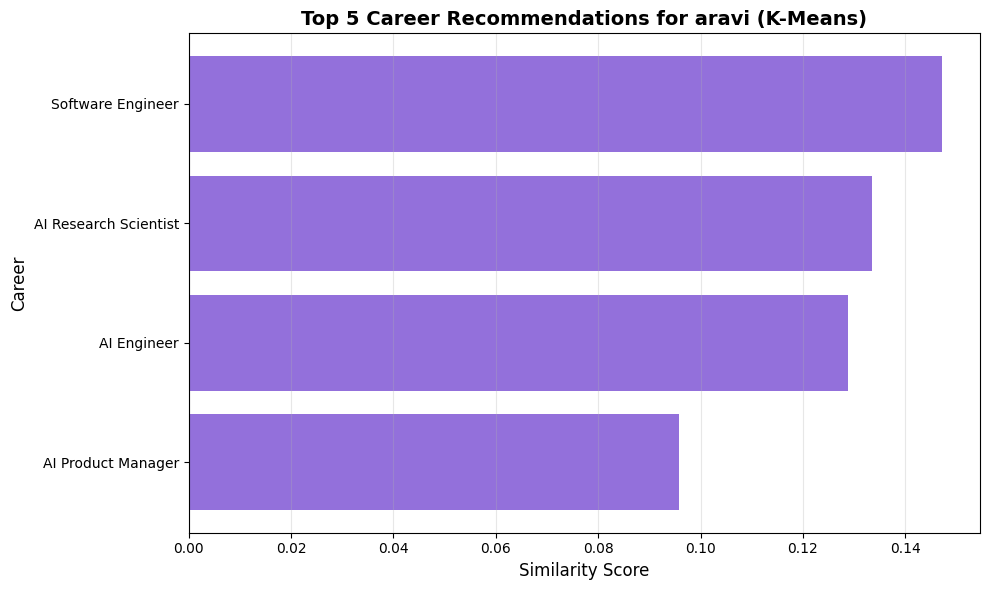

✅ Visualization complete!


In [9]:
import matplotlib.pyplot as plt

# Extract data for visualization
career_names = [rec['career_name'] for rec in recommendations]
scores = [rec['similarity_score'] for rec in recommendations]

# Create bar plot
plt.figure(figsize=(10, 6))
plt.barh(career_names, scores, color='mediumpurple')
plt.xlabel('Similarity Score', fontsize=12)
plt.ylabel('Career', fontsize=12)
plt.title(f'Top 5 Career Recommendations for {user_profile["name"]} (K-Means)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Visualization complete!")

## Step 10: Visualize Cluster Distribution (Optional)

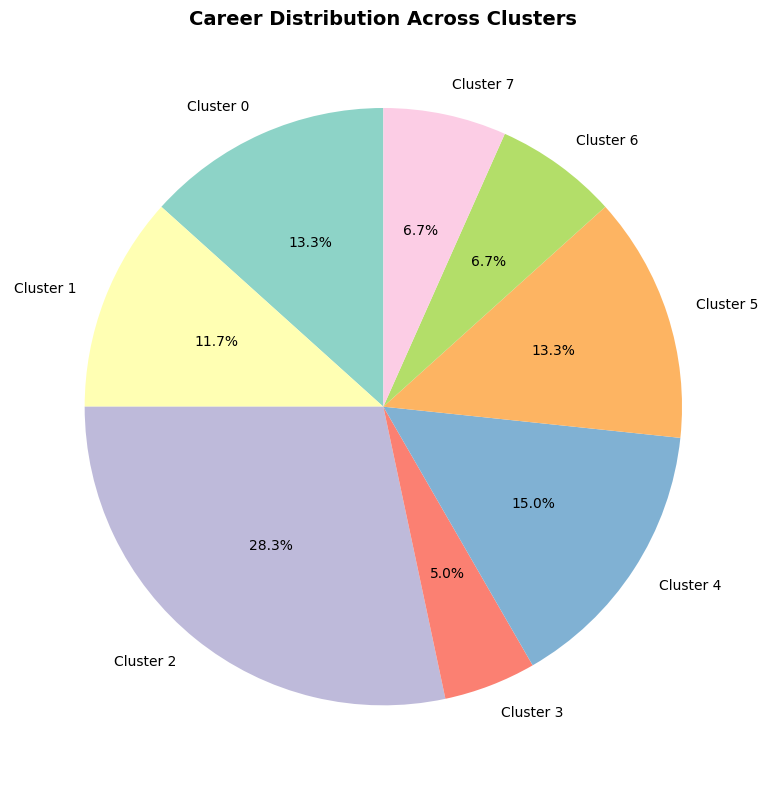

✅ Cluster distribution visualization complete!


In [10]:
# Cluster distribution pie chart
cluster_counts = careers_df['cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 8))
colors = plt.cm.Set3(range(len(cluster_counts)))
plt.pie(cluster_counts, labels=[f'Cluster {i}' for i in cluster_counts.index], 
        autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Career Distribution Across Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Cluster distribution visualization complete!")

## Step 11: Analyze User's Cluster (Optional)

In [11]:
# Show all careers in user's cluster
user_text = ' '.join([
    user_profile.get('department', ''),
    user_profile.get('interests', ''),
    ' '.join(user_profile.get('skills', [])),
    ' '.join(user_profile.get('projects', [])),
    ' '.join(user_profile.get('certifications', []))
])

user_vector = tfidf.transform([user_text])
user_cluster = kmeans.predict(user_vector)[0]

cluster_careers = careers_df[careers_df['cluster'] == user_cluster]

print(f"\n📦 All Careers in Your Cluster (Cluster {user_cluster}):\n")
print(f"Total: {len(cluster_careers)} careers\n")

for idx, (_, row) in enumerate(cluster_careers.iterrows(), 1):
    print(f"{idx}. {row['career_name']} - {row.get('category', 'N/A')}")

print(f"\n✅ Cluster analysis complete!")


📦 All Careers in Your Cluster (Cluster 5):

Total: 8 careers

1. Software Engineer - Computer Science
2. AI Research Scientist - Artificial Intelligence and Research
3. AI Engineer - Artificial Intelligence
4. Biomedical Engineer - nan
5. AI Research Scientist - nan
6. AI Product Manager - nan
7. Quantum Computing Researcher - nan
8. Agricultural Technologist - nan

✅ Cluster analysis complete!
